dx_ref = 0.05263, dt_sc = 0.00200, strips = 500
Generating FD reference...
Running integrator...
Done. 10000 points,  mean err = 1.078e-03,  max err = 1.280e-02


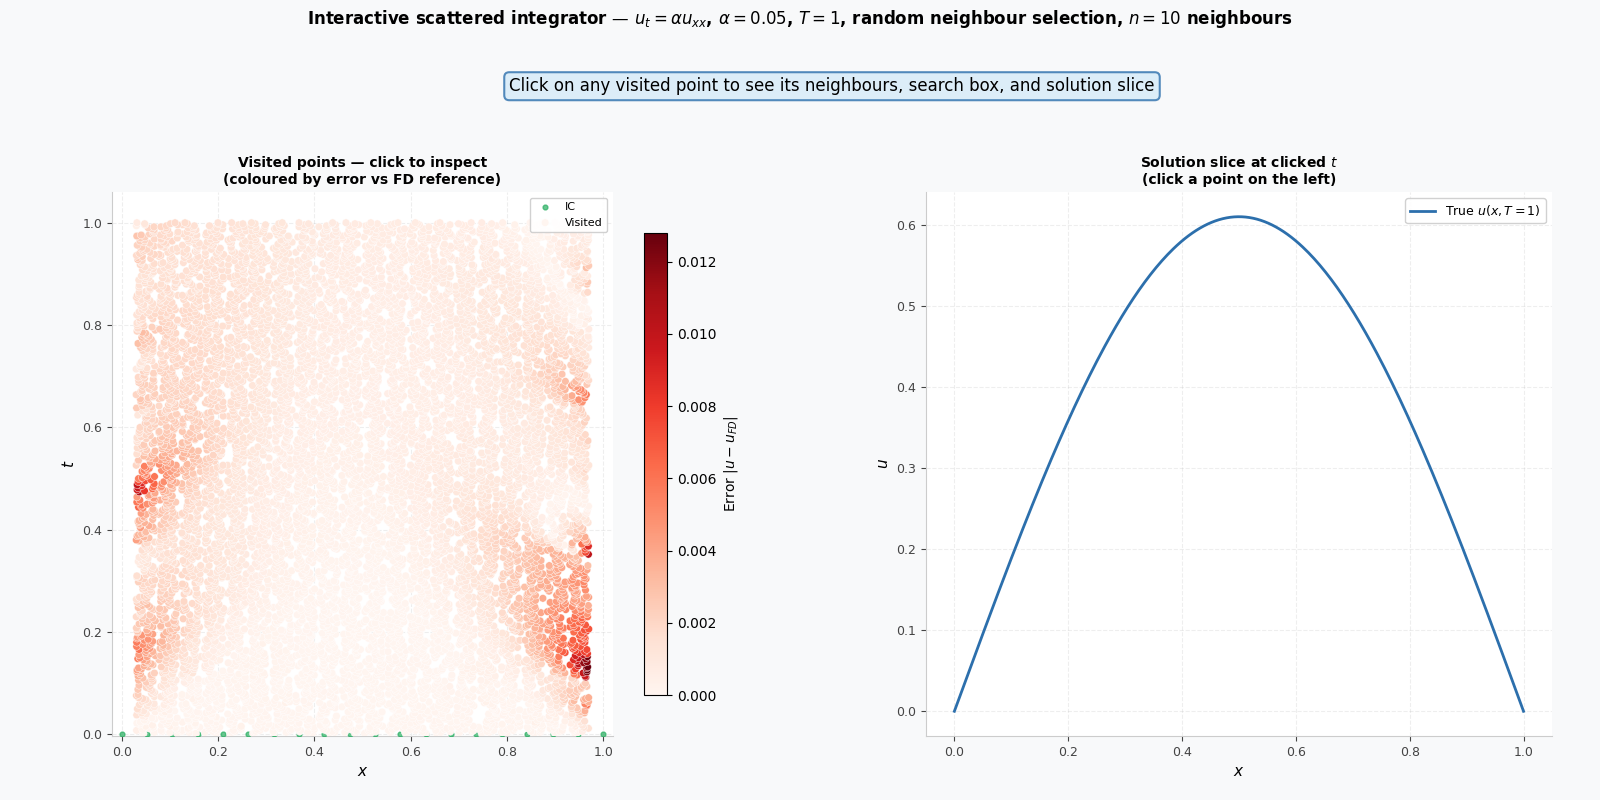

In [ ]:
import numpy as np
%matplotlib widget
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as patches
from matplotlib.colors import Normalize

np.random.seed(42)

# ─────────────────────────────────────────────
# Parameters
# ─────────────────────────────────────────────
alpha    = 0.05
T        = 1

nx_sc    = 20          # points per strip
n_exact  = 10           # neighbours to use
box_x0   = 0.15        # initial box half-width in x
box_t0   = 0.01        # initial box look-back in t
box_xmax = 0.5
box_tmax = T
box_grow = 1.5
cond_max = 1e8

dx_ref = 1.0 / (nx_sc - 1)
dt_sc  = 0.002         # choose directly

t_strips = np.arange(0, T + dt_sc, dt_sc)

print(f"dx_ref = {dx_ref:.5f}, dt_sc = {dt_sc:.5f}, strips = {len(t_strips)-1}")

# ─────────────────────────────────────────────
# True solution and FD reference
# ─────────────────────────────────────────────
def u_true(x, t):
    return np.exp(-alpha * np.pi**2 * t) * np.sin(np.pi * x)

def generate_fd_reference(nx=200, dt=1e-4):
    x = np.linspace(0, 1, nx)
    dx = x[1] - x[0]

    lam = alpha * dt / dx**2   # computed internally

    if lam > 0.3:
        print(f"Warning: scheme may be unstable (λ = {lam:.3f})")

    nt = int(T / dt) + 1

    U = np.zeros((nt, nx))
    U[0] = u_true(x, 0)
    for k in range(nt-1):

        # interior (4th order)
        U[k+1,2:-2] = (
            U[k,2:-2]
            + lam/12 * (
                -U[k,4:]
                + 16*U[k,3:-1]
                - 30*U[k,2:-2]
                + 16*U[k,1:-3]
                - U[k,:-4]
            )
        )

        # near boundaries (2nd order)
        U[k+1,1] = U[k,1] + lam*(U[k,2] - 2*U[k,1] + U[k,0])
        U[k+1,-2] = U[k,-2] + lam*(U[k,-1] - 2*U[k,-2] + U[k,-3])

        # Dirichlet BCs
        U[k+1,0] = 0
        U[k+1,-1] = 0
    return x, np.arange(nt) * dt, U

print("Generating FD reference...")
x_fd, t_fd, U_fd = generate_fd_reference()

def fd_interp(xq, tq):
    ix = np.clip(np.searchsorted(x_fd, xq) - 1, 0, len(x_fd) - 2)
    it = np.clip(np.searchsorted(t_fd, tq) - 1, 0, len(t_fd) - 2)

    tx = (xq - x_fd[ix]) / (x_fd[ix + 1] - x_fd[ix])
    tt = (tq - t_fd[it]) / (t_fd[it + 1] - t_fd[it])

    return (
        (1 - tt) * (1 - tx) * U_fd[it, ix]
        + (1 - tt) * tx * U_fd[it, ix + 1]
        + tt * (1 - tx) * U_fd[it + 1, ix]
        + tt * tx * U_fd[it + 1, ix + 1]
    )

# ─────────────────────────────────────────────
# Weight solver
# ─────────────────────────────────────────────
def solve_weights(dx_i, dt_i):
    h   = max(np.max(np.abs(dx_i)), 1e-12)
    tau = max(np.max(np.abs(dt_i)), 1e-12)

    xi = dx_i / h
    s  = dt_i / tau

    lam = alpha * tau / h**2

    A = np.array([
        np.ones(len(dx_i)),        # constant
        xi,                        # first spatial derivative
        0.5 * xi**2 + lam * s,     # diffusion term
        xi**3 / 6,                 # third derivative
        xi**4 / 24                 # fourth derivative
    ])

    b = np.array([1.0, 0.0, 0.0, 0.0, 0.0])


    cond = np.linalg.cond(A)
    w = np.linalg.lstsq(A, b, rcond=None)[0]

    return w, cond

# ─────────────────────────────────────────────
# Neighbour search
# ─────────────────────────────────────────────
def find_neighbours(x_star, t_star, visited):
    bx, bt = box_x0, box_t0

    while True:
        nb = [
            p for p in visited
            if abs(p[0] - x_star) <= bx
            and 0 < (t_star - p[1]) <= bt
        ]

        if len(nb) >= n_exact:
            nb.sort(key=lambda p: (p[0] - x_star)**2 + (p[1] - t_star)**2)
            return nb[:n_exact]

        bx = min(bx * box_grow, box_xmax)
        bt = min(bt * box_grow, box_tmax)

        if bx >= box_xmax and bt >= box_tmax:
            return None

# ─────────────────────────────────────────────
# Run integrator
# ─────────────────────────────────────────────
visited = []
point_data = []

x_ic = np.linspace(0, 1, nx_sc)
for xi in x_ic:
    visited.append((xi, 0.0, u_true(xi, 0.0)))

print("Running integrator...")
for t_star in t_strips[1:]:
    for xbc in [0.0, 1.0]:
        visited.append((xbc, t_star, 0.0))

    x_cands = np.linspace(0.05, 0.95, nx_sc) + np.random.uniform(-0.02, 0.02, nx_sc)
    x_cands = np.clip(x_cands, 0.02, 0.98)
    np.random.shuffle(x_cands)

    for x_star in x_cands:
        nb = find_neighbours(x_star, t_star, visited)
        if nb is None:
            continue

        nb_pts = np.array(nb)
        dx_i = nb_pts[:, 0] - x_star
        dt_i = nb_pts[:, 1] - t_star
        u_i = nb_pts[:, 2]

        w, cond = solve_weights(dx_i, dt_i)
        if cond > cond_max:
            continue

        u_hat = w @ u_i
        visited.append((x_star, t_star, u_hat))

        u_ref = fd_interp(x_star, t_star)

        point_data.append({
            'x': x_star,
            't': t_star,
            'u': u_hat,
            'err': abs(u_hat - u_ref),
            'w1': np.sum(np.abs(w)),
            'cond': cond,
            'nb_x': nb_pts[:, 0].copy(),
            'nb_t': nb_pts[:, 1].copy(),
            'nb_u': nb_pts[:, 2].copy(),
            'box_x': np.max(np.abs(dx_i)),
            'box_t': np.max(np.abs(dt_i)),
        })

print(
    f"Done. {len(point_data)} points,  "
    f"mean err = {np.mean([p['err'] for p in point_data]):.3e},  "
    f"max err = {np.max([p['err'] for p in point_data]):.3e}"
)

px   = np.array([p['x'] for p in point_data])
pt   = np.array([p['t'] for p in point_data])
pu   = np.array([p['u'] for p in point_data])
perr = np.array([p['err'] for p in point_data])

ic_x = x_ic
ic_t = np.zeros(len(ic_x))

# ─────────────────────────────────────────────
# Interactive figure
# ─────────────────────────────────────────────
BLUE   = '#2C6FAC'
ORANGE = '#E87722'
RED    = '#C0392B'
GREEN  = '#27AE60'
GREY   = '#7F8C8D'

fig = plt.figure(figsize=(16, 8))
fig.patch.set_facecolor('#F8F9FA')
gs = gridspec.GridSpec(
    2, 2,
    height_ratios=[0.1, 0.9],
    hspace=0.25,
    wspace=0.3,
    left=0.07,
    right=0.97,
    top=0.93,
    bottom=0.08
)

def style_ax(ax):
    ax.set_facecolor('white')
    ax.spines[['top', 'right']].set_visible(False)
    ax.spines[['left', 'bottom']].set_color('#CCCCCC')
    ax.tick_params(colors='#444444', labelsize=9)
    ax.grid(True, alpha=0.2, linestyle='--', color='#AAAAAA')

# ── Info bar ──────────────────────────────────
ax_text = fig.add_subplot(gs[0, :])
ax_text.axis('off')
text_display = ax_text.text(
    0.5, 0.5,
    'Click on any visited point to see its neighbours, search box, and solution slice',
    ha='center', va='center', fontsize=12,
    bbox=dict(
        boxstyle='round',
        facecolor='#D6EAF8',
        alpha=0.8,
        edgecolor=BLUE,
        linewidth=1.5
    )
)

ax_left  = fig.add_subplot(gs[1, 0])
ax_right = fig.add_subplot(gs[1, 1])
style_ax(ax_left)
style_ax(ax_right)

# IC points
ax_left.scatter(ic_x, ic_t, s=12, color=GREEN, zorder=3, label='IC', alpha=0.7)

# Visited points coloured by error
sc = ax_left.scatter(
    px, pt,
    c=perr,
    cmap='Reds',
    s=30,
    zorder=4,
    edgecolors='white',
    linewidths=0.3,
    norm=Normalize(vmin=0, vmax=max(perr.max(), 1e-10)),
    label='Visited'
)
plt.colorbar(sc, ax=ax_left, label='Error $|u - u_{FD}|$', shrink=0.85)

ax_left.set_xlim(-0.02, 1.02)
ax_left.set_ylim(-0.003, T * 1.06)
ax_left.set_xlabel('$x$', fontsize=11)
ax_left.set_ylabel('$t$', fontsize=11)
ax_left.set_title(
    'Visited points — click to inspect\n(coloured by error vs FD reference)',
    fontsize=10,
    fontweight='bold'
)
ax_left.legend(fontsize=8, framealpha=0.9, edgecolor='#CCCCCC')

# Right panel default
x_plot = np.linspace(0, 1, 300)
ax_right.plot(
    x_plot, u_true(x_plot, T), '-',
    color=BLUE, linewidth=2,
    label=f'True $u(x, T={T})$'
)
ax_right.set_xlabel('$x$', fontsize=11)
ax_right.set_ylabel('$u$', fontsize=11)
ax_right.set_title(
    'Solution slice at clicked $t$\n(click a point on the left)',
    fontsize=10,
    fontweight='bold'
)
ax_right.legend(fontsize=9, framealpha=0.9, edgecolor='#CCCCCC')

























# ─────────────────────────────────────────────
# Click handler
# ─────────────────────────────────────────────
_interactive_artists = []

def clear_interactive():
    for artist in _interactive_artists:
        try:
            artist.remove()
        except Exception:
            pass
    _interactive_artists.clear()

def on_click(event):
    if event.inaxes != ax_left or event.button != 1:
        return

    xc, tc = event.xdata, event.ydata
    if xc is None or tc is None:
        return

    # nearest point in display (pixel) space
    xy_disp = ax_left.transData.transform(np.column_stack([px, pt]))
    click_disp = ax_left.transData.transform([[xc, tc]])[0]
    dists = np.sqrt(np.sum((xy_disp - click_disp)**2, axis=1))
    idx = int(np.argmin(dists))

    if dists[idx] > 20:
        return

    p = point_data[idx]
    xq = p['x']
    tq = p['t']
    uq = p['u']
    eq = p['err']

    clear_interactive()

    # search box
    bx = p['box_x']
    bt = p['box_t']
    rect = patches.Rectangle(
        (xq - bx, tq - bt),
        2 * bx,
        bt,
        linewidth=1.8,
        edgecolor=RED,
        facecolor=RED,
        alpha=0.07,
        zorder=2
    )
    ax_left.add_patch(rect)
    _interactive_artists.append(rect)

    # lines to neighbours
    for xi, ti in zip(p['nb_x'], p['nb_t']):
        line, = ax_left.plot(
            [xq, xi], [tq, ti], '-',
            color=BLUE, linewidth=1.2, alpha=0.5, zorder=3
        )
        _interactive_artists.append(line)

    # neighbour markers
    nb_sc = ax_left.scatter(
        p['nb_x'], p['nb_t'],
        s=80, color=BLUE, marker='s', zorder=5,
        edgecolors='white', linewidths=0.8
    )
    _interactive_artists.append(nb_sc)

    # clicked point
    node = ax_left.scatter(
        [xq], [tq],
        s=180, color=RED, marker='o', zorder=6,
        edgecolors='black', linewidths=1.2
    )
    _interactive_artists.append(node)

    # info bar update
    text_display.set_text(
        f'Point: ({xq:.3f}, {tq:.4f})  |  '
        f'Predicted: {uq:.5f}  |  '
        f'True: {u_true(xq, tq):.5f}  |  '
        f'Error: {eq:.2e}  |  '
        f'||w||_1: {p["w1"]:.3f}  |  '
        f'cond(A): {p["cond"]:.1e}  |  '
        f'neighbours: {len(p["nb_x"])}'
    )

    # right panel: solution slice at tq
    ax_right.cla()
    style_ax(ax_right)

    ax_right.plot(
        x_plot, u_true(x_plot, tq), '-',
        color=BLUE, linewidth=2,
        label=f'True $u(x, t={tq:.3f})$'
    )

    u_fd_slice = np.array([fd_interp(xi, tq) for xi in x_plot])
    ax_right.plot(
        x_plot, u_fd_slice, '--',
        color=GREEN, linewidth=1.8,
        label='FD reference'
    )

    tol = dt_sc * 0.6
    mask = np.abs(pt - tq) < tol

    if mask.sum() > 1:
        xs = px[mask]
        us = pu[mask]
        order = np.argsort(xs)
        xs = xs[order]
        us = us[order]

        ax_right.plot(
            xs, us, '-o',
            color=ORANGE,
            linewidth=2,
            markersize=5,
            label='Your method'
        )

    ax_right.scatter(
        [xq], [uq],
        s=150, color=RED, zorder=5,
        marker='*', edgecolors='black', linewidths=0.8,
        label='Clicked point'
    )

    ax_right.scatter(
        p['nb_x'], p['nb_u'],
        s=80, color=BLUE, marker='s', zorder=5,
        edgecolors='white', linewidths=0.8, alpha=0.7,
        label='Neighbours used'
    )

    ax_right.set_xlabel('$x$', fontsize=11)
    ax_right.set_ylabel('$u$', fontsize=11)
    ax_right.set_title(f'Solution slice at $t = {tq:.4f}$', fontsize=10, fontweight='bold')
    ax_right.legend(fontsize=8.5, framealpha=0.9, edgecolor='#CCCCCC')

    fig.canvas.draw()

fig.canvas.mpl_connect('button_press_event', on_click)

fig.suptitle(
    rf'Interactive scattered integrator — $u_t = \alpha u_{{xx}}$, '
    rf'$\alpha = {alpha}$, $T = {T}$, random neighbour selection, '
    rf'$n = {n_exact}$ neighbours',
    fontsize=12, fontweight='bold', y=0.99
)

plt.show()